In [5]:
!pip install kaggle

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'"username":"https://www.kaggle.com/kaurtavleen",key":"KGAT_84f1ea0e262423d63ec14e52454b021a"'}

In [7]:
!mv "kaggle.json" kaggle.json

mv: 'kaggle.json' and 'kaggle.json' are the same file


In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download fivethirtyeight/uber-pickups-in-new-york-city

Dataset URL: https://www.kaggle.com/datasets/fivethirtyeight/uber-pickups-in-new-york-city
License(s): CC0-1.0
  0% 0.00/109M [00:00<?, ?B/s]
100% 109M/109M [00:00<00:00, 1.22GB/s]


In [ ]:
!unzip uber-pickups-in-new-york-city.zip

Archive:  uber-pickups-in-new-york-city.zip
  inflating: Uber-Jan-Feb-FOIL.csv   
  inflating: other-American_B01362.csv  
  inflating: other-Carmel_B00256.csv  
  inflating: other-Dial7_B00887.csv  
  inflating: other-Diplo_B01196.csv  
  inflating: other-FHV-services_jan-aug-2015.csv  
  inflating: other-Federal_02216.csv  
  inflating: other-Firstclass_B01536.csv  
  inflating: other-Highclass_B01717.csv  
  inflating: other-Lyft_B02510.csv   
  inflating: other-Prestige_B01338.csv  
  inflating: other-Skyline_B00111.csv  
  inflating: uber-raw-data-apr14.csv  
  inflating: uber-raw-data-aug14.csv  
  inflating: uber-raw-data-janjune-15.csv  
  inflating: uber-raw-data-jul14.csv  
  inflating: uber-raw-data-jun14.csv  
  inflating: uber-raw-data-may14.csv  
  inflating: uber-raw-data-sep14.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Dataset loading
df = pd.read_csv("uber-raw-data-apr14.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (564516, 4)


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [ ]:
# Data Preprocessing
df["timestamp"] = pd.to_datetime(df["Date/Time"])

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

df["weekend"] = (df["day_of_week"] >= 5).astype(int)

In [ ]:
demand_data = df.groupby("hour").size().reset_index(name="demand")

In [ ]:
#Add Context Features (Rain + Event)
demand_data["rain"] = np.random.choice([0,1], len(demand_data))

demand_data["event"] = np.random.choice([0,1], len(demand_data))

In [ ]:
X = demand_data[["hour","rain","event"]]

y = demand_data["demand"]

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
# Model evaluation
print("MAE:", mean_absolute_error(y_test, predictions))

print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))

print("R2 Score:", r2_score(y_test, predictions))

MAE: 2860.822
RMSE: 3451.171917436163
R2 Score: 0.9247446991894229


In [ ]:
#Scenario Prediction
scenario = pd.DataFrame({
    "hour":[20],
    "rain":[1],
    "event":[1]
})

prediction = model.predict(scenario)

print("Predicted Taxi Demand:", prediction[0])

Predicted Taxi Demand: 36301.52


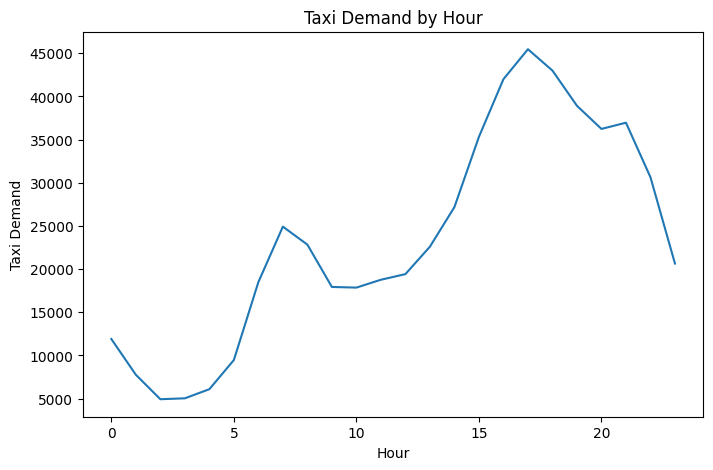

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(demand_data["hour"], demand_data["demand"])
plt.xlabel("Hour")
plt.ylabel("Taxi Demand")
plt.title("Taxi Demand by Hour")
plt.show()